## Importing btrack and loading example datasets

In [28]:
import btrack

from btrack import datasets

We can automatically download some example data to play with:

In [30]:
CONFIG_FILE = datasets.cell_config()
# SEGMENTATION_FILE = datasets.example_segmentation_file()
# OBJECTS_FILE = datasets.example_track_objects_file()

## Finding objects to track

### Use case 1 - Objects from segmentation

These could be objects found using algorithms such as a UNet, *CellPose* or *StarDist*. We can use `scikit-image` to load the segmentation data, which returns a numpy array of dimensions (T, Y, X).

In [31]:
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.util import montage

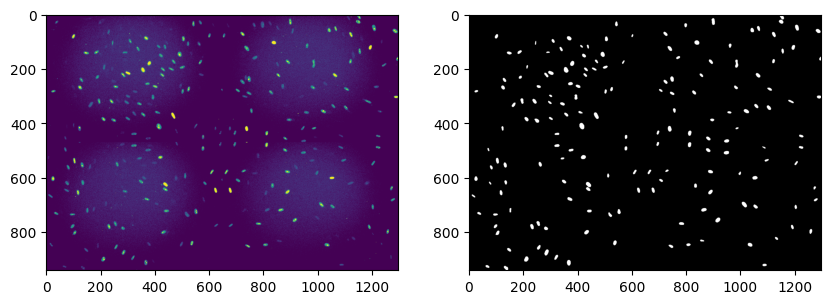

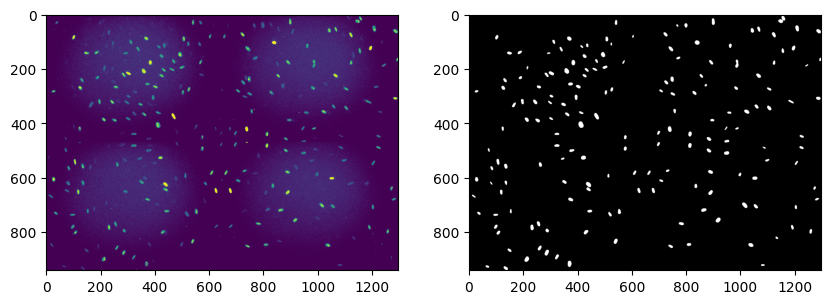

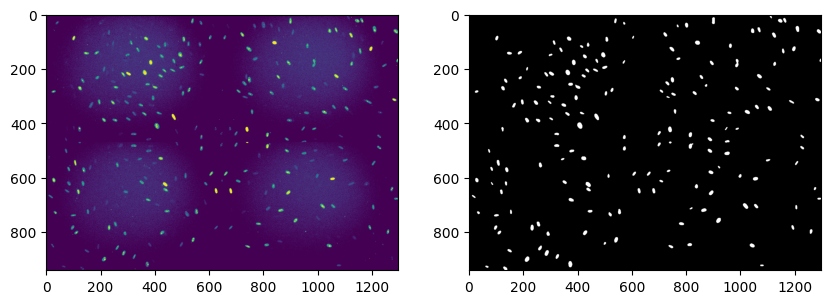

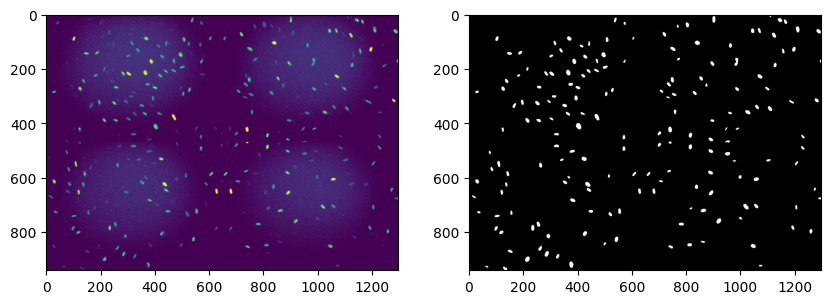

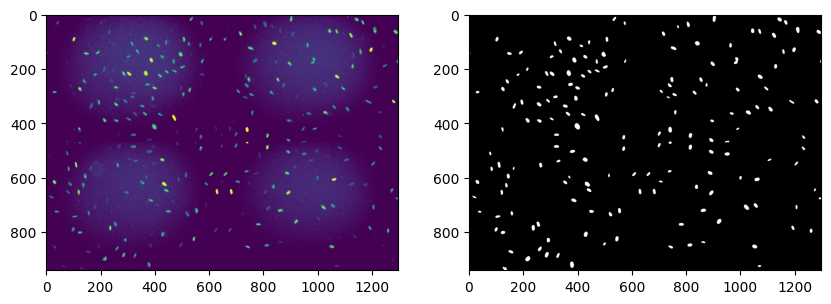

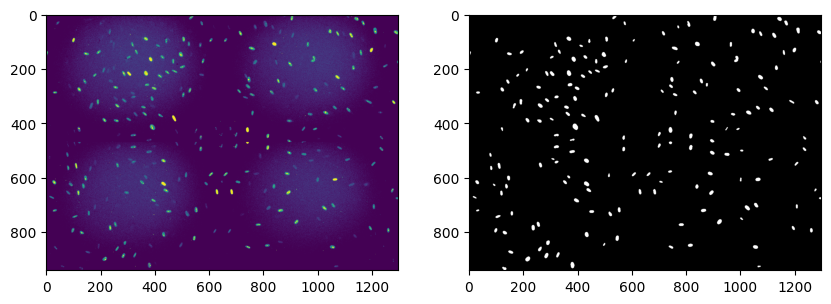

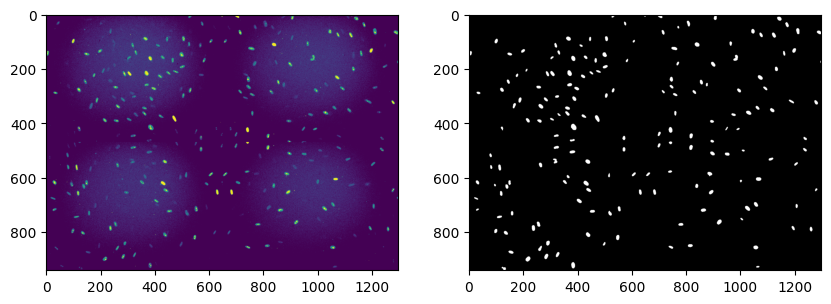

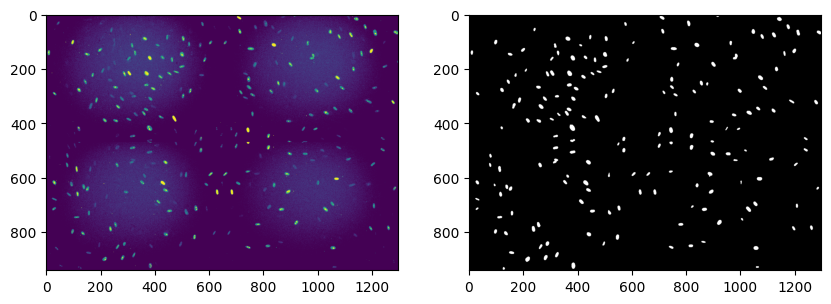

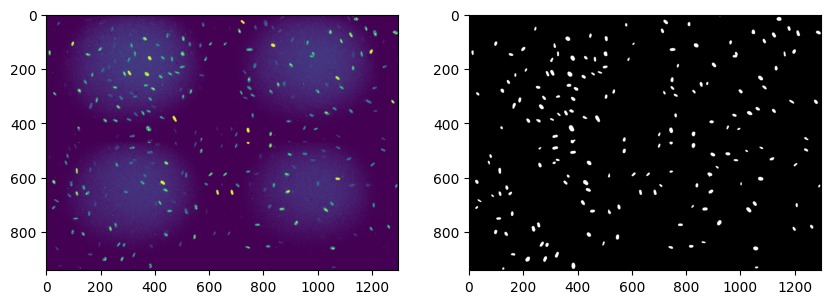

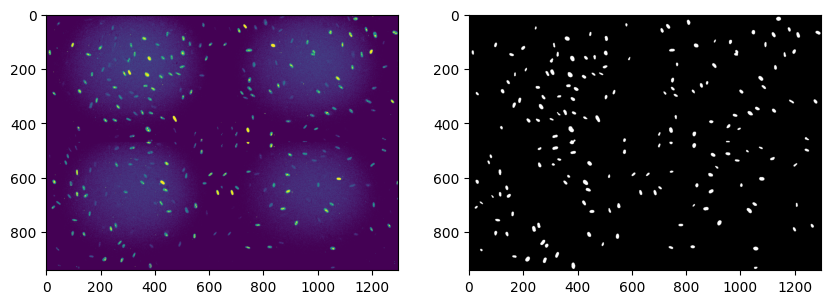

In [33]:
# Reload tifffiles back
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np
from skimage import io

basepath = '/scratch/indikar_root/indikar1/shared_data/HYB/Imaging'
sample = 'Myod'
sample_id = 1
num_frames = 10
channel = 'cy5'
# num_frames = 30

cmap = ListedColormap(['black', 'white'])

original_imgs = [
    io.imread(f'{basepath}/original_images/{channel}/{sample}_{sample_id}_frame_{t:03d}.tif')
    for t in range(1, num_frames+1)
]

segmentation_masks = [
    io.imread(f'{basepath}/segmentation_masks/{channel}/{sample}_{sample_id}_frame_{t:03d}.tif')
    for t in range(1, num_frames+1)
]

# Convert to numpy arrays
originals = np.stack(original_imgs)
segmentations = np.stack(segmentation_masks)


for i in range(num_frames):
    img = originals[i]
    mask = segmentations[i]
    full_mask = mask.copy()
    mask[mask > 1] = 1
    
    # print(mask)
    # print(mask.min(), mask.max())
    fig, ax = plt.subplots(1, 2, figsize=(10, 10))
    ax1, ax2 = ax
    ax1.imshow(img)
    ax2.imshow(mask, cmap = cmap)

In [128]:
# Reload tifffiles back
import matplotlib.pyplot as plt
import numpy as np
from skimage import io


# num_frames = 66
num_frames = 60
# num_frames = 30

original_cy5_imgs = [
    io.imread(f'mosaic_tiffs/original/{t}_cy5.tif')
    for t in range(1, num_frames)
]

original_mkate_imgs = [
    io.imread(f'mosaic_tiffs/original/{t}_mkate.tif')
    for t in range(1, num_frames)
]

cy5_segmentation_masks = [
    io.imread(f'mosaic_tiffs/segmentation/{t}_cy5.tif')
    for t in range(1, num_frames)
]

graphs = [
    io.imread(f'mosaic_graphs/{t}.png')
    for t in range(1, num_frames)
]

imagexshape, imageyshape = original_cy5_imgs[0].shape

graphr = [
    io.imread(f'mosaic_graphs/{t}.png')[::, ::, :1].reshape(500, 1000)
    for t in range(1, num_frames)
]
graphg = [
    io.imread(f'mosaic_graphs/{t}.png')[::, ::, 1:2].reshape(500, 1000)
    for t in range(1, num_frames)
]
graphb = [
    io.imread(f'mosaic_graphs/{t}.png')[::, ::, 2:3].reshape(500, 1000)
    for t in range(1, num_frames)
]

graph_stack = np.zeros((num_frames, imagexshape+500, imageyshape+1000))  # 10 time points

offset_x = imagexshape + 300
offset_y = int(imageyshape//4.5)

stack_with_image_r = np.zeros_like(graph_stack)
stack_with_image_g = np.zeros_like(graph_stack)
stack_with_image_b = np.zeros_like(graph_stack)

for i in range(num_frames-1):
    stack_with_image_r[i, offset_y:offset_y+500, offset_x:offset_x+1000] = image_to_add = graphr[i]
    stack_with_image_g[i, offset_y:offset_y+500, offset_x:offset_x+1000] = image_to_add = graphg[i]
    stack_with_image_b[i, offset_y:offset_y+500, offset_x:offset_x+1000] = image_to_add = graphb[i]


# Convert to numpy arrays
original_imgs = np.stack(original_cy5_imgs)
# original_imgs = np.stack(original_mkate_imgs)
segmentation_masks = np.stack(cy5_segmentation_masks)

segmentation = segmentation_masks

# for i in range(num_frames):
#     img = original_cy5_imgs[i]
#     mask = cy5_segmentation_masks[i]
#     fig, ax = plt.subplots(figsize=(10, 10))
#     ax.imshow(img)

In [88]:
original_cy5_imgs[0].shape
# segmentation_masks.shape
# segmentation = segmentation_masks

(942, 1298)

In [ ]:
segmentation_masks

### show the segmentation as a montage

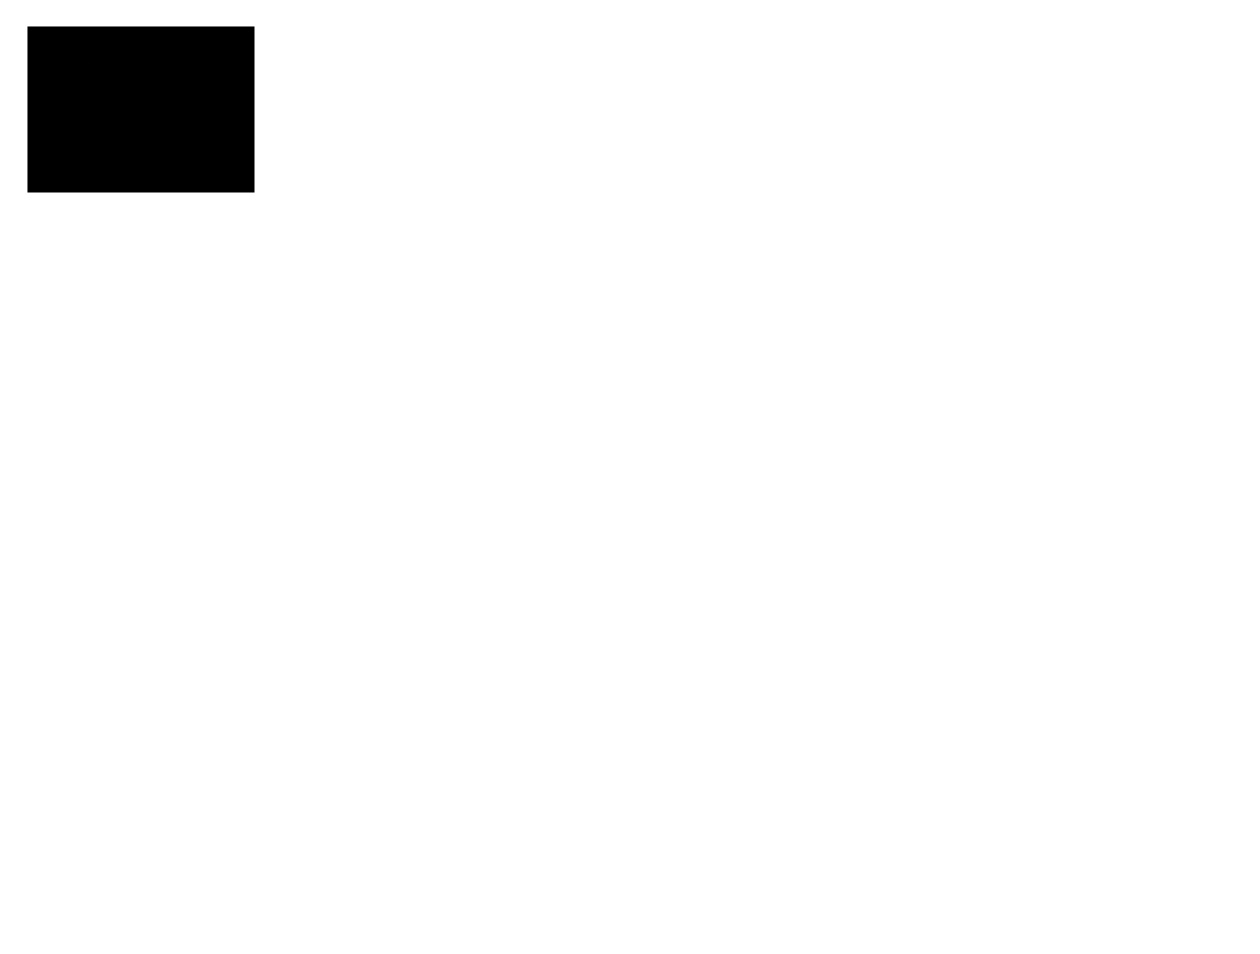

In [34]:
seq = montage(
    segmentations[::20, ::10, ::10], 
    grid_shape=(5, 5), 
    padding_width=10, 
    fill=255,
)

fig, ax = plt.subplots(1, figsize=(16, 16))
ax.imshow(seq, cmap=plt.cm.gray)
ax.axis(False)
plt.show()

### localize the objects

Now we use a utility function to localise the objects in the segmentation. Note that we can also use scikit-image `regionprops` to calculate properties for each object, using the `properties` keyword:

In [35]:
FEATURES = [
    "area", 
    "major_axis_length", 
    "minor_axis_length", 
    "orientation", 
    "solidity"
]

objects = btrack.utils.segmentation_to_objects(
    segmentations, 
    properties=tuple(FEATURES), 
    num_workers=4,  # parallelise this
)

[INFO][2025/06/19 04:12:07 PM] Localizing objects from segmentation...
[INFO][2025/06/19 04:12:07 PM] Processing using 4 workers.
progress: 100%|██████████| 10/10 [00:01<00:00,  6.91it/s]
[INFO][2025/06/19 04:12:08 PM] Objects are of type: <class 'dict'>
[INFO][2025/06/19 04:12:08 PM] ...Found 1773 objects in 10 frames.


We can also inspect each returned object to determine it's properties:

In [38]:
objects[0]
# len(objects)

,ID,x,y,z,t,dummy,states,label,area,major_axis_length,minor_axis_length,orientation,solidity
0,0,1150.373737,9.964646,0.0,0,False,7,5,198.0,21.3106,11.888685,0.547013,0.956522


In [39]:
btrack.SystemInformation()

btrack_version: 0.6.5
system_platform: Linux-4.18.0-553.50.1.el8_10.x86_64-x86_64-with-glibc2.28
system_python: 3.10.16

## Run Tracking

In [40]:
# initialise a tracker session using a context manager
with btrack.BayesianTracker() as tracker:

    # configure the tracker using a config file
    tracker.configure(CONFIG_FILE)
    tracker.max_search_radius = 50
    tracker.tracking_updates = ["MOTION", "VISUAL"]
    tracker.features = FEATURES

    # append the objects to be tracked
    tracker.append(objects)

    # set the tracking volume
    tracker.volume=((0, 1600), (0, 1200))

    # track them (in interactive mode)
    tracker.track(step_size=100)

    # generate hypotheses and run the global optimizer
    tracker.optimize()

    # get the tracks in a format for napari visualization
    data, properties, graph = tracker.to_napari()
    
    # store the tracks
    tracks = tracker.tracks
    
    # store the configuration
    cfg = tracker.configuration
    
    # export the track data 
    # tracker.export("tracks.h5", obj_type="obj_type_1")
    

[INFO][2025/06/19 04:15:42 PM] Loaded btrack: /home/nuvi/btrack/btrack/libs/libtracker.so
[INFO][2025/06/19 04:15:42 PM] Starting BayesianTracker session
[INFO][2025/06/19 04:15:42 PM] Loading configuration file: /home/nuvi/.cache/btrack-examples/examples/cell_config.json
[INFO][2025/06/19 04:15:42 PM] Objects are of type: <class 'list'>
[INFO][2025/06/19 04:15:42 PM] Starting tracking... 
[INFO][2025/06/19 04:15:42 PM] Update using: ['MOTION', 'VISUAL']
[INFO][2025/06/19 04:15:42 PM] Tracking objects in frames 0 to 10 (of 10)...
[INFO][2025/06/19 04:15:42 PM]  - Timing (Bayesian updates: 4.93ms, Linking: 0.87ms)
[INFO][2025/06/19 04:15:42 PM]  - Probabilities (Link: 1.00000, Lost: 0.81423)
[INFO][2025/06/19 04:15:42 PM] SUCCESS.
[INFO][2025/06/19 04:15:42 PM]  - Found 204 tracks in 10 frames (in 0.0s)
[INFO][2025/06/19 04:15:42 PM]  - Inserted 21 dummy objects to fill tracking gaps
[INFO][2025/06/19 04:15:42 PM] Loading hypothesis model: cell_hypothesis
[INFO][2025/06/19 04:15:42 PM] 

GLPK Integer Optimizer 5.0
816 rows, 612 columns, 816 non-zeros
612 integer variables, all of which are binary
Preprocessing...
408 rows, 612 columns, 816 non-zeros
612 integer variables, all of which are binary
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  1.000e+00  ratio =  1.000e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 408
Solving LP relaxation...
GLPK Simplex Optimizer 5.0
408 rows, 612 columns, 816 non-zeros
*     0: obj =   2.053692330e+02 inf =   0.000e+00 (16)
*    16: obj =   1.510104994e+02 inf =   0.000e+00 (0)
OPTIMAL LP SOLUTION FOUND
Integer optimization begins...
Long-step dual simplex will be used
+    16: mip =     not found yet >=              -inf        (1; 0)
+    16: >>>>>   1.510104994e+02 >=   1.510104994e+02   0.0% (1; 0)
+    16: mip =   1.510104994e+02 >=     tree is empty   0.0% (0; 1)
INTEGER OPTIMAL SOLUTION FOUND


## Inspecting the output

We can also inspect each returned track to determine it's properties:

In [41]:
cell = tracks[1]

In [42]:
cell

,ID,t,x,y,z,parent,root,state,generation,dummy,orientation,minor_axis_length,solidity,major_axis_length,area
0,109,0,460.063063,201.963964,0.0,109,109,5,0,False,1.086253,7.378063,0.948718,19.152366,111.0
1,109,1,462.400000,203.000000,0.0,109,109,5,0,False,1.110806,7.716015,0.937500,19.799910,120.0
2,109,2,464.961240,206.116279,0.0,109,109,5,0,False,1.099464,8.001001,0.914894,20.601596,129.0
3,109,3,468.359375,207.406250,0.0,109,109,5,0,False,1.087974,7.941051,0.941176,20.590840,128.0
4,109,4,470.900000,208.716667,0.0,109,109,5,0,False,1.137909,7.773754,0.916031,19.751565,120.0
5,109,5,471.778689,209.409836,0.0,109,109,5,0,False,1.142691,7.842263,0.903704,19.880255,122.0
6,109,6,475.495238,210.961905,0.0,109,109,5,0,False,1.215842,7.107604,0.945946,18.739602,105.0
7,109,7,477.770642,211.954128,0.0,109,109,5,0,False,1.250789,7.276473,0.939655,19.015531,109.0
8,109,8,480.904255,214.404255,0.0,109,109,5,0,False,1.236497,6.778672,0.912621,17.681908,94.0
9,109,9,485.588235,219.529412,0.0,109,109,5,0,False,1.114256,6.180995,0.904255,17.595733,85.0


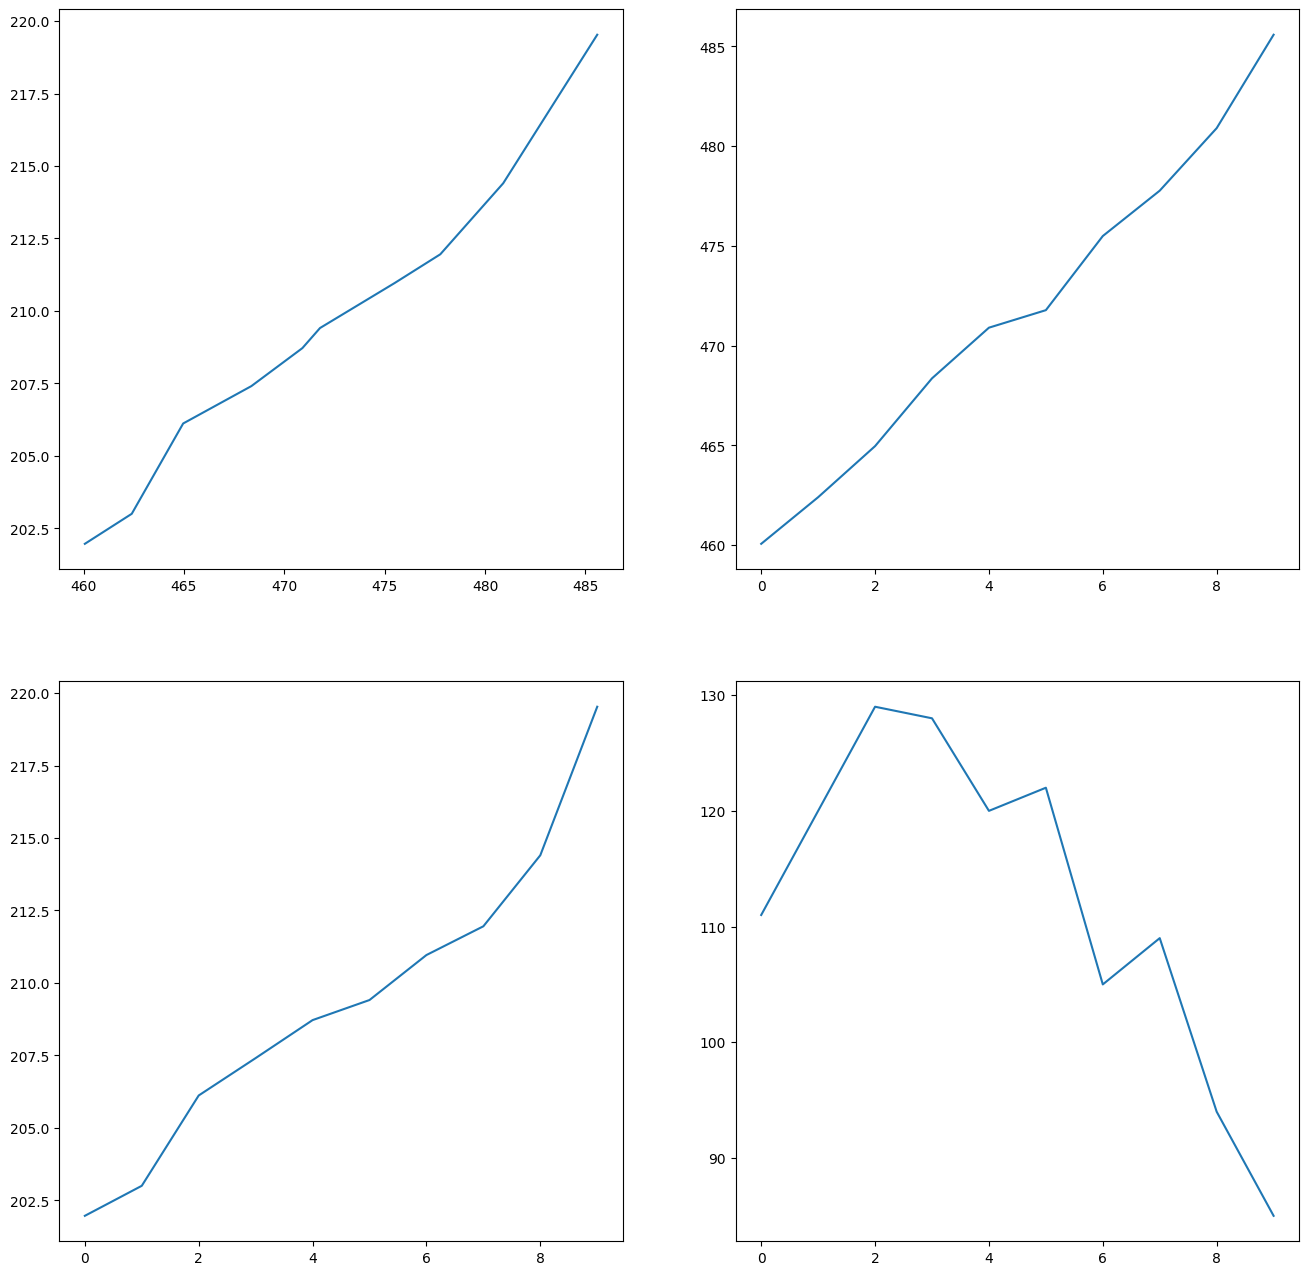

In [43]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 16))
ax1.plot(cell.x, cell.y)
ax2.plot(cell.t, cell.x)
ax3.plot(cell.t, cell.y)
ax4.plot(cell.t, cell["area"])
plt.show()

## Visualising the data with napari

Finally, we an inspect the entire tracking output using *napari*:

In [135]:
import napari


viewer = napari.Viewer()

viewer.add_image(
    segmentation, 
    name="Segmentation",
    opacity=0.3,
)

viewer.add_image(
    original_imgs, 
    name="Original Images",
    opacity=0.75,
)

# the track data from the tracker
viewer.add_tracks(
    data, 
    properties=properties, 
    graph=graph,
    name="Tracks", 
    blending="translucent",
    visible=True,
)

viewer.add_image(
    stack_with_image_r, 
    name="Graphr",
    colormap='red',
    opacity=0.7,
    blending='additive',
)
viewer.add_image(
    stack_with_image_g, 
    name="Graphg",
    colormap='green',
    opacity=0.7,
    blending='additive',
)
viewer.add_image(
    stack_with_image_b, 
    name="Graphb",
    colormap='blue',
    opacity=0.7,
    blending='additive',
)

napari.run()

Rendering frames...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 60/60 [00:26<00:00,  2.25it/s]


In [ ]:
import napari


viewer = napari.Viewer()

viewer.add_image(
    segmentation, 
    name="Segmentation",
    opacity=0.5,
)

viewer.add_image(
    graphs, 
    name="PLOT",
    opacity=0.5,
)

# # the track data from the tracker
# viewer.add_tracks(
#     data, 
#     properties=properties, 
#     graph=graph,
#     name="Tracks", 
#     blending="translucent",
#     visible=True,
# )

napari.run()

In [33]:
# from napari.utils import nbscreenshot


# nbscreenshot(viewer)

In [54]:
import imageio

path_to_save_gif = 'gif.gif'

ims = [
    imageio.imread(f'mosaic_graphs/{t}.png')
    for t in range(num_frames)
]

imageio.mimwrite(path_to_save_gif, ims)

/var/folders/bw/k47pyks15hj5krd7g8r02s_c0000gn/T/ipykernel_90361/4144399679.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  imageio.imread(f'mosaic_graphs/{t}.png')


In [53]:
len(original_cy5_imgs)

59

In [34]:
# import sample data
from skimage.data import cells3d

import napari

# create a `Viewer` and `Image` layer here
viewer, image_layer = napari.imshow(cells3d())

# print shape of image data
print(image_layer.data.shape)

# start the event loop and show the viewer
napari.run()

(60, 2, 256, 256)


In [20]:
from skimage import data

import napari

viewer, image_layer = napari.imshow(data.astronaut(), rgb=True)

In [76]:
len(ims)

60

In [79]:
len(segmentation)

59